In [ ]:
import sys
from pathlib import Path
import tempfile, py7zr
import geopandas as gpd
import matplotlib.pyplot as plt

# Find the repo root (folder containing "functions/") and add it + its parent to sys.path
repo = Path.cwd()
while not (repo / "functions").exists() and repo.parent != repo:
    repo = repo.parent
sys.path[:0] = [str(repo), str(Path.cwd().parent.parent)]

from constants import *
from cs_plotting import plot_comap
from functions.plot_hillshade import plot_hillshade
from utils import plt_counties, COUNTIES_PATH

### PLOT BASE COMPA MAP LAYER ###

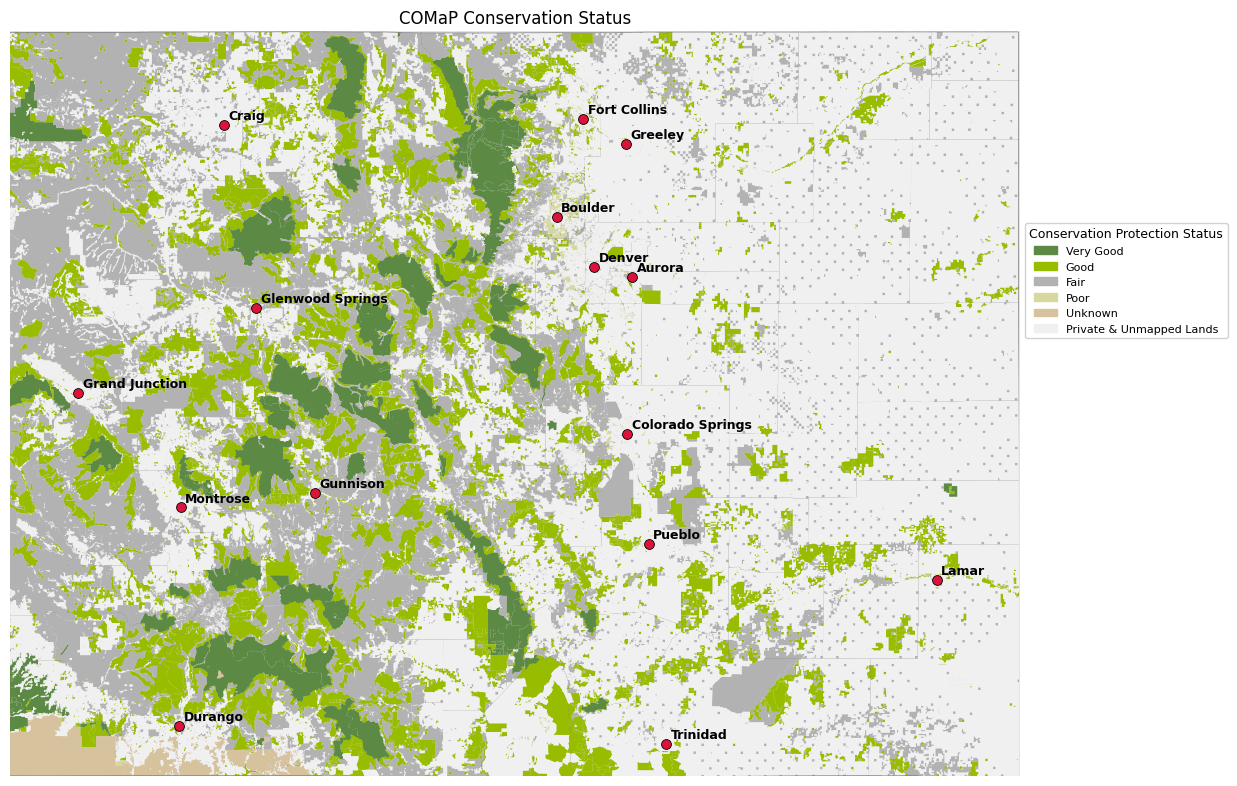

In [ ]:
with tempfile.TemporaryDirectory() as tmp:
    py7zr.SevenZipFile(COMPAP_PATH).extractall(tmp)
    shp = next(Path(tmp).rglob("*.shp"))
    gdf = gpd.read_file(shp).set_crs("EPSG:26913", allow_override=True)

# Hillshade base
fig, ax = plot_hillshade()

# Counties on top
plt_counties(COUNTIES_PATH, county_edgecolor="gray", county_linewidth=1.0, ax=ax)

# Full styled COMaP on top
plot_comap(gdf, ax=ax, title="COMaP Conservation Status")

plt.tight_layout()
plt.show()

### PLOT SINGLE COMAP LEVEL WITH GEOTIFS ###

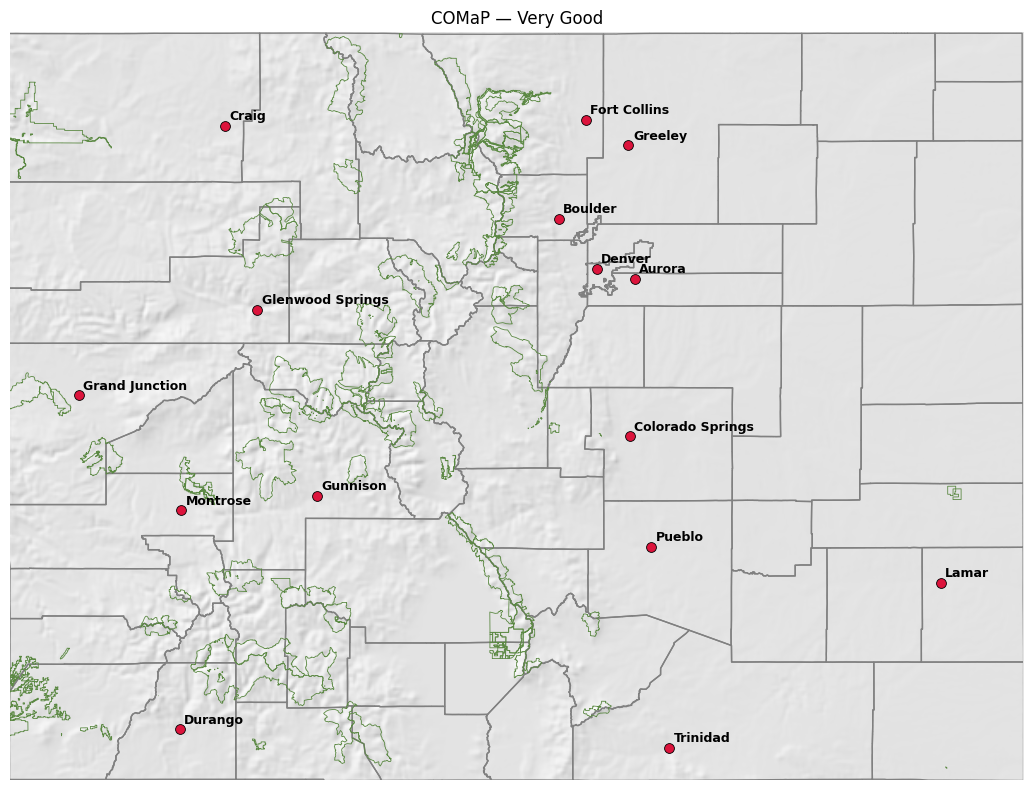

In [4]:
# Load COMaP and reproject to match the hillshade/counties (Web Mercator)
with tempfile.TemporaryDirectory() as tmp:
    py7zr.SevenZipFile(COMPAP_PATH).extractall(tmp)
    shp = next(Path(tmp).rglob("*.shp"))
    gdf = (
        gpd.read_file(shp)
        .set_crs("EPSG:26913", allow_override=True)
        .to_crs("EPSG:3857")
    )

# Pick one FinalModSt level to outline
LEVEL = "V"
subset = gdf[gdf["FinalModSt"] == LEVEL]

# Build the layered figure
fig, ax = plot_hillshade()
plt_counties(COUNTIES_PATH, county_edgecolor="gray", county_linewidth=1.0, ax=ax)
subset.plot(ax=ax, facecolor="none",
            edgecolor=FINALMODST_COLORS[LEVEL], linewidth=0.6)

ax.set_title(f"COMaP — {FINALMODST_LABELS[LEVEL]}")
ax.set_axis_off()
plt.tight_layout()
plt.show()